In [1]:
from pickle import load
from decimal import Decimal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde

import ssefcca_functions as sfc

In [2]:
data_folder = 'data'

clf_file = f'{data_folder}/models/poly_svm.pkl'

csv_file = f'{data_folder}/csv_files/experimental_application.csv'

outputs_folder = f'{data_folder}/plots/experimental_application'

In [3]:
df = pd.read_csv(csv_file)
print(f'Total # of signals: {len(df)}')
df = df[~df['Molecular Formula'].isna()]
print(f'Total # of assigned formulae: {len(df)}')
df = df.fillna(0)

df['C'] += df['13C']
df['S'] += df['34S']
df['O'] += df['18O'] + df['17O']
df.drop(columns=['13C','34S','18O','17O'],inplace=True)

elements = ['O','H','N']
for e in elements:
    col = f'{e}/C'
    if col not in df.columns:
        df[col] = df[e] / df['C']

Total # of signals: 5130
Total # of assigned formulae: 3195


In [4]:
# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

def plot_2d3d(df,colour_list_2d,colour_list_3d,savepath=None,cmap='RdBu',cbar_title=None,
              xlim=(0, 1.5),ylim=(.1, 2.5),zlim=(0, .35)):

  fig = plt.figure(figsize=(13, 6),layout='constrained')

  # 2D Plot (subplot a)
  ax_2d = fig.add_subplot(121)

  if all([not isinstance(x,str) for x in colour_list_2d]):
    comb = np.array([colour_list_2d,colour_list_3d]).flatten()
    norm = Normalize(vmin=np.min(comb),vmax=np.max(comb))

  ax_2d.scatter(df['O/C'], df['H/C'],
                        c=colour_list_2d,
                        cmap = None if any([isinstance(x,str) for x in colour_list_2d]) else cmap,
                        norm = None if any([isinstance(x,str) for x in colour_list_2d]) else norm,
                        lw=.1,edgecolors='k',
                        s=10)

  ax_2d.set_xlabel('O/C', fontsize=14)
  ax_2d.set_ylabel('H/C', fontsize=14)

  combos = [['O/C','x',0.25,xlim],
            ['H/C','y',0.3,ylim],]
  for combo in combos:
    sfc.set_axis_ticks(df[combo[0]], ax_2d, axis=combo[1], major_ticks_interval=combo[2], minor_ticks_interval=None,
                       rounding=1, lower_lim=combo[3][0], upper_lim=combo[3][1])

  # 3D Plot (subplot b)
  ax_3d = fig.add_subplot(122, projection='3d')

  map3d = ax_3d.scatter(df['O/C'], df['H/C'], df['N/C'],
                c=colour_list_3d,
                cmap = None if any([isinstance(x,str) for x in colour_list_3d]) else cmap,
                norm = None if any([isinstance(x,str) for x in colour_list_3d]) else norm,
                lw=.2,edgecolors='k',
                s=10)

  combos = [['O/C','x',0.25,xlim],
            ['H/C','y',0.4,ylim],
            ['N/C','z',0.1,zlim]]
  for combo in combos:
    sfc.set_axis_ticks(df[combo[0]], ax_3d, axis=combo[1], major_ticks_interval=combo[2], minor_ticks_interval=None,
                      rounding=1, lower_lim=combo[3][0], upper_lim=combo[3][1])


  ax_3d.view_init(elev=15, azim=-60)

  ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
  ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
  ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

  ax_3d.set_box_aspect(None, zoom=1.15)

  # Add subplot labels
  ax_2d.set_title('(a)', fontsize=20)
  ax_3d.set_title('(b)', fontsize=20)

  # colourbar
  if all([not isinstance(x,str) for x in colour_list_2d]):
    middle_value = (np.min(comb)+np.max(comb)) / 2
    above_middle = (np.max(comb)+middle_value)/2
    below_middle = (np.min(comb)+middle_value)/2
    cbar_ticks = [np.min(comb),below_middle,middle_value,above_middle,np.max(comb)]

    cax = ax_3d.inset_axes([1.25, 0.0, 0.05, 1.025])
    cbar = fig.colorbar(map3d, cax=cax,ax=[ax_2d, ax_3d],
                        ticks=cbar_ticks,)
    
    cbar.set_label(cbar_title,fontsize=14)

  if savepath is not None:
    fig.savefig(savepath, dpi=400, facecolor='#fff', bbox_inches='tight')

  return fig, ax_2d, ax_3d

In [5]:
xy = np.vstack([df['O/C'].to_numpy(),df['H/C'].to_numpy()])
xyz = np.vstack([df['O/C'].to_numpy(),df['H/C'].to_numpy(),df['N/C'].to_numpy()])
kde_2d = gaussian_kde(xy)(xy)
kde_3d = gaussian_kde(xyz)(xyz)
kde_2d /= np.sum(kde_2d) / 1e4
kde_3d /= np.sum(kde_3d) / 1e4

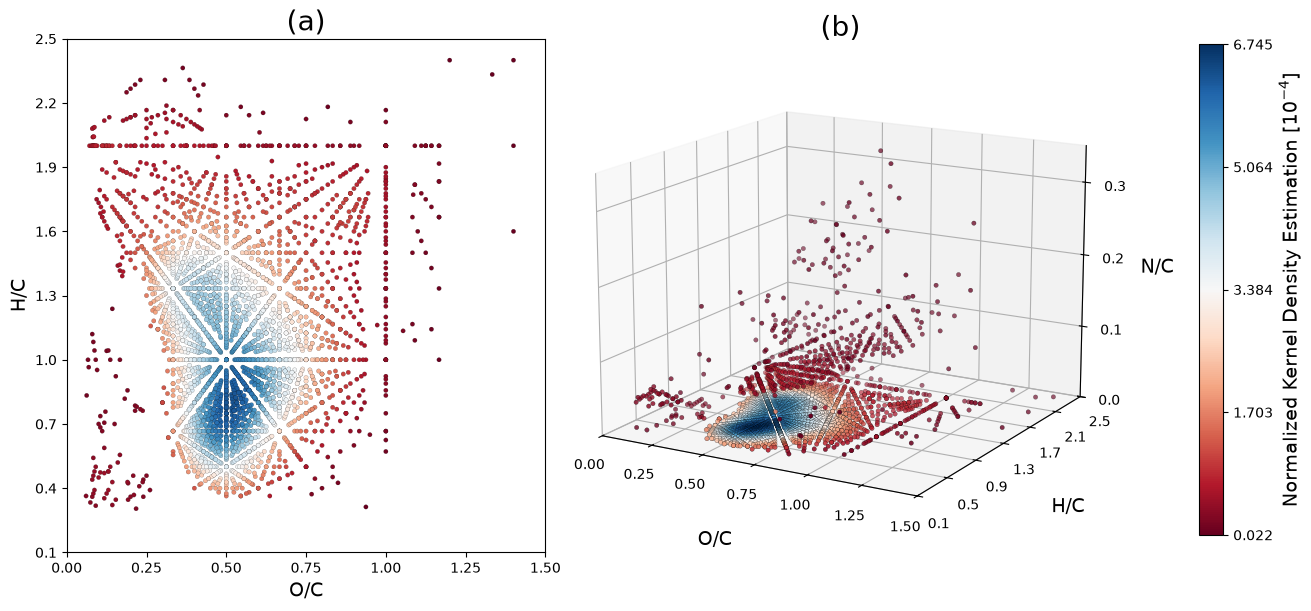

In [6]:
fig, ax_2d, ax_3d = plot_2d3d(df,kde_2d,kde_3d,
                              cbar_title='Normalized Kernel Density Estimation [$10^{-4}$]',
                              savepath=f'{outputs_folder}/vk_distribution.svg')

In [7]:
# load the model
with open(clf_file, 'rb') as f:
        ssefcca = load(f)

In [8]:
X = df[['O/C','H/C','N/C']].to_numpy()

y_pred = ssefcca.predict(X)
proba = ssefcca.predict_proba(X)
proba = np.max(proba,axis=1)*100

Total number of formulas: 3195
Total number of amino sugar-like: 82 (2.57%)
Total number of carbohydrate-like: 234 (7.32%)
Total number of lignin-like: 1137 (35.59%)
Total number of lipid-like: 559 (17.5%)
Total number of PAH-like: 47 (1.47%)
Total number of peptide-like: 41 (1.28%)
Total number of tannin-like: 1095 (34.27%)


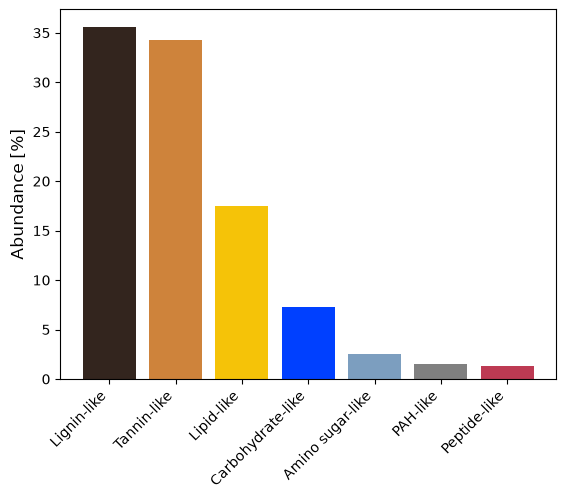

In [9]:
tot_form = len(y_pred)
print(f'Total number of formulas: {tot_form}')

labels = []
percs = []

y_pred_unique = np.unique(y_pred)
for cat in y_pred_unique:
    label = cat.replace('_',' ') if cat != 'pah' else 'PAH'
    label += '-like'
    labels.append(label.capitalize() if label != 'PAH-like' else label)

    i = np.where(y_pred==cat)[0]
    tot = len(i)
    perc = 100*len(i) / tot_form
    percs.append(perc)
    perc = np.round(perc,2)

    print(f'Total number of {label}: {tot} ({perc}%)')

fig, ax = plt.subplots()

labels = np.array(labels)
percs = np.array(percs)
idxs = np.argsort(percs)[::-1]
c = [sfc.vk_region_colours[x] for x in y_pred_unique[idxs]]
ax.bar(labels[idxs],percs[idxs], color=c)
ax.set_ylabel('Abundance [%]',fontsize=12)
ax.set_xticks(range(len(labels)),labels[idxs],
              rotation=45,ha='right')

fig.savefig(f'{outputs_folder}/assignment_abundance.svg', dpi=400, facecolor='#fff', bbox_inches='tight')

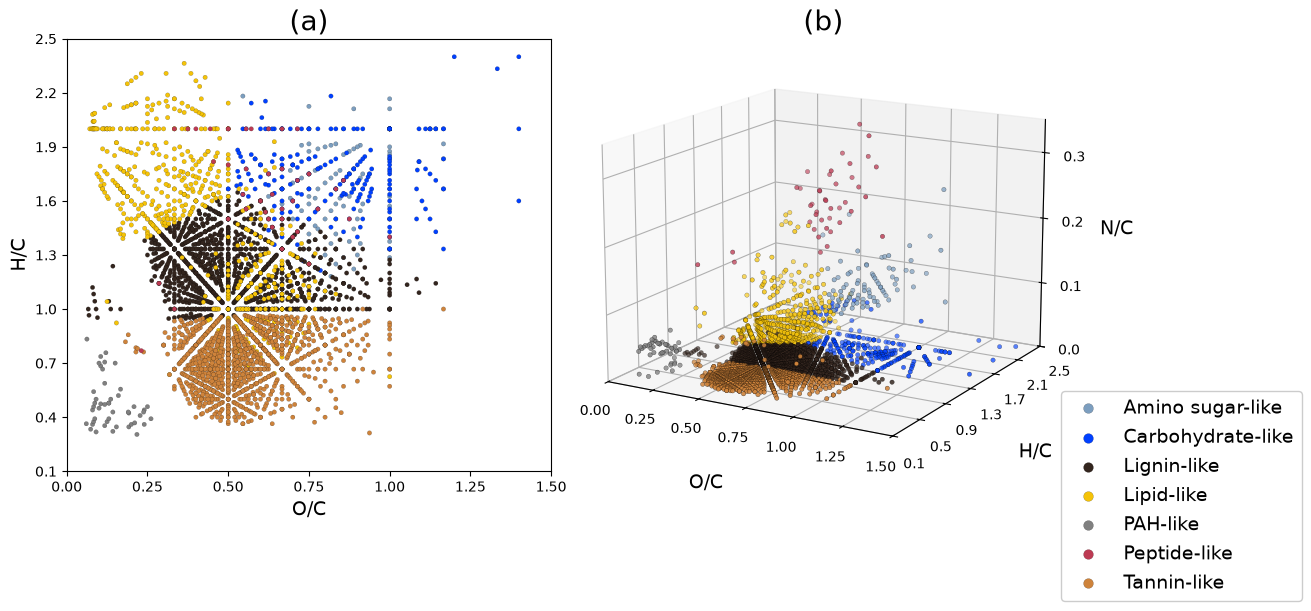

In [10]:
class_colours = np.array([sfc.vk_region_colours[x] for x in y_pred])

order = ['amino_sugar', 'carbohydrate', 'lignin', 'lipid', 'pah', 'tannin', 'peptide']# incerasing desired zorder

ordered_indices = []
for cat in order:
    ordered_indices += list(np.where(y_pred==cat)[0])
ordered_indices = np.array(ordered_indices)

fig, ax_2d, ax_3d = plot_2d3d(df.iloc[ordered_indices],class_colours[ordered_indices],class_colours[ordered_indices])

for cat in y_pred_unique:
    label = cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH'
    ax_3d.scatter(10,10,10,
                  c=sfc.vk_region_colours[cat],
                  lw=.1,edgecolors='k',
                  s=50,
                  label=label+'-like')

ax_3d.legend(framealpha=1, bbox_to_anchor=(1.05, -0.3), loc='lower left', borderaxespad=0, fontsize=14)

fig.savefig(f'{outputs_folder}/vk_class_assignment.svg', dpi=400, facecolor='#fff', bbox_inches='tight')

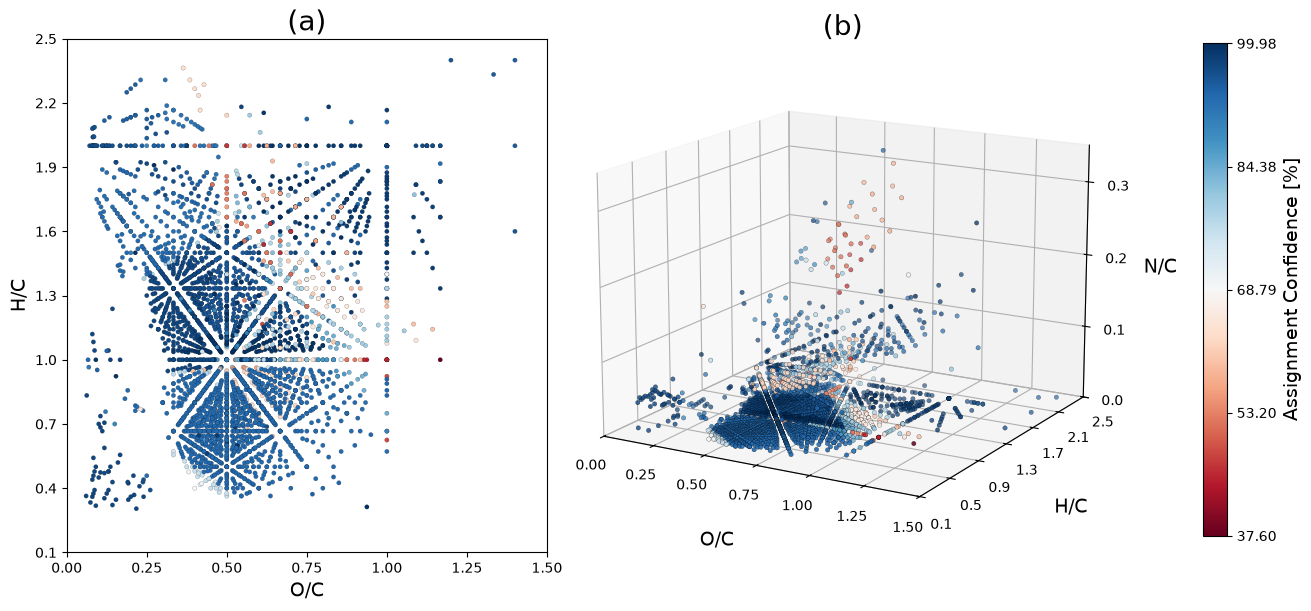

In [11]:
fig, ax_2d, ax_3d = plot_2d3d(df.iloc[ordered_indices],proba[ordered_indices],proba[ordered_indices],
                              cbar_title='Assignment Confidence [%]')

fig.savefig(f'{outputs_folder}/vk_assignment_confidence.svg', dpi=400, facecolor='#fff', bbox_inches='tight')

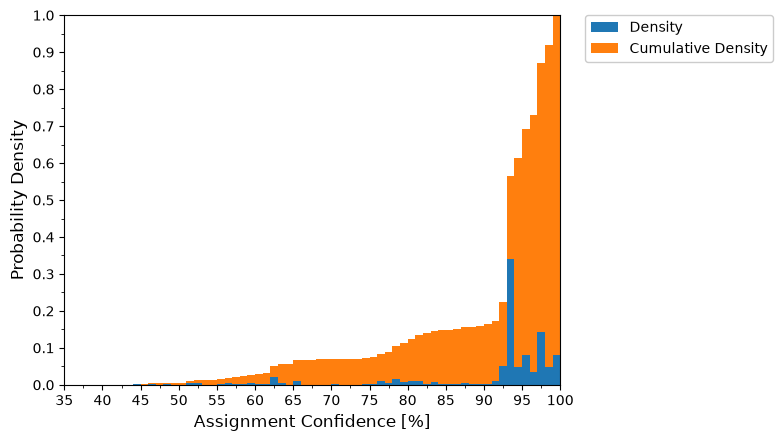

In [12]:
fig, ax = plt.subplots()
limits = np.arange(37,101,1)
n, bins, patches = ax.hist(proba,bins=limits,density=True,label='Density')
n, bins, patches = ax.hist(proba,bins=limits,density=True,cumulative=True,zorder=-1,label='Cumulative Density')

ax.legend(framealpha=1,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

sfc.set_axis_ticks(None, ax, axis='y', major_ticks_interval=0.1, minor_ticks_interval=0.05,
                   rounding=2, lower_lim=0, upper_lim=1)
sfc.set_axis_ticks(None, ax, axis='x', major_ticks_interval=5, minor_ticks_interval=2.5,
                   rounding=0, lower_lim=35, upper_lim=100)

ax.set_xlabel('Assignment Confidence [%]',fontsize=12)
ax.set_ylabel('Probability Density',fontsize=12)

fig.savefig(f'{outputs_folder}/confidence_density_distr_tot.svg', dpi=400, facecolor='#fff', bbox_inches='tight')

In [13]:
for i in range(len(bins)-1):
    print(f'Cumulative density of values < {bins[i+1]}: {n[i]}')

Cumulative density of values < 38.0: 0.00031298904538341156
Cumulative density of values < 39.0: 0.00031298904538341156
Cumulative density of values < 40.0: 0.00031298904538341156
Cumulative density of values < 41.0: 0.00031298904538341156
Cumulative density of values < 42.0: 0.00031298904538341156
Cumulative density of values < 43.0: 0.00031298904538341156
Cumulative density of values < 44.0: 0.00031298904538341156
Cumulative density of values < 45.0: 0.0025039123630672924
Cumulative density of values < 46.0: 0.0031298904538341154
Cumulative density of values < 47.0: 0.004381846635367762
Cumulative density of values < 48.0: 0.004381846635367762
Cumulative density of values < 49.0: 0.005320813771517997
Cumulative density of values < 50.0: 0.005320813771517997
Cumulative density of values < 51.0: 0.00594679186228482
Cumulative density of values < 52.0: 0.00970266040688576
Cumulative density of values < 53.0: 0.013771517996870111
Cumulative density of values < 54.0: 0.013771517996870111


In [14]:
probs = {}
for cat in y_pred_unique:
    i = np.where(y_pred==cat)[0]

    label = cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH'
    label += '-like'
    probs[label] = proba[i]

    avg = np.mean(probs[label])
    std = np.std(probs[label])

    scientific = ('%.0E' % Decimal(std)).split('E')
    dec_places = -int(scientific[1])
    avg = np.round(avg,dec_places)
    std = np.round(std,dec_places)
    if std >= 1:
        avg = int(avg)
        std = int(std)

    print(f'{label} assignment confidence: {avg} ± {std} %')

Amino sugar-like assignment confidence: 94 ± 6 %
Carbohydrate-like assignment confidence: 90 ± 10 %
Lignin-like assignment confidence: 90 ± 10 %
Lipid-like assignment confidence: 90 ± 10 %
PAH-like assignment confidence: 97 ± 2 %
Peptide-like assignment confidence: 60 ± 20 %
Tannin-like assignment confidence: 92 ± 5 %


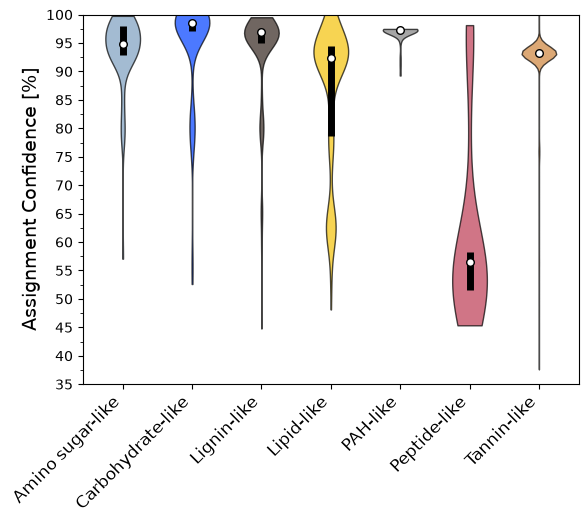

In [15]:
fig, ax = sfc.draw_violinplot(probs,ylabel='Assignment Confidence [%]',
                              colours=[sfc.vk_region_colours[y] for y in y_pred_unique],alpha=.7)

sfc.set_axis_ticks(None, ax, axis='y', major_ticks_interval=5, minor_ticks_interval=2.5,
                   rounding=0, lower_lim=35, upper_lim=100)

fig.savefig(f'{outputs_folder}/confidence_density_distr_by_class.svg', dpi=400, facecolor='#fff', bbox_inches='tight')